# Cross-Device Operator Breakdown: Desktop GPU vs. NVIDIA Jetson Nano

This notebook visualizes and compares the **GPU kernel time breakdown** of multiple LLM architectures across two hardware platforms during the **prefill phase**:

| Platform | Device |
|----------|--------|
| Desktop  | NVIDIA GPU (server-class, e.g. A100 / H100) |
| Edge     | NVIDIA Jetson Orin Nano|

Models span three architecture families:

| Family | Models |
|--------|--------|
| **Transformer** | GPT-Neo-125m, TinyLlama, LLaMA-3.2, Qwen2.5-Instruct, Qwen2.5-1.5B-Instruct |
| **State Space Model (SSM)** | Mamba-130m, Mamba2-130m |
| **Hybrid** | Zamba2, Hymba |

Execution time at a fixed sequence length (default **1024 tokens**) is decomposed into the same operator categories used in [`plotting_ops.ipynb`](plotting_ops.ipynb):

| Category | Description |
|----------|-------------|
| **GEMM** | General Matrix Multiplications (linear projections, convolutions) |
| **SSM_Scan** | State space model recurrence scan |
| **activation** | Activation functions (SiLU, GeLU, etc.) |
| **arithmetic** | Element-wise and reduction ops (add, mul, exp, sum, …) |
| **memory** | Data movement ops (reshape, permute, cat, copy, …) |
| **nomralization** | Layer norm and RMS norm |
| **embedding** | Token embedding lookup |
| **logit_computation** | Softmax for output logits |
| **pooling / interpolation / roi / other** | Miscellaneous ops |

Profiling data is read from `../../profile_data/` (desktop) and `../../profile_data_jetson/` (Jetson). The resulting side-by-side bar chart is saved as `device_comparison_seq<N>.png`.

In [1]:
import os
import pandas as pd
import matplotlib
from matplotlib import pyplot as plot

gemm_file = "gemm.csv"
non_gemm_file = "non_gemm.csv"
ssm_scan_file = "ssm_scan.csv"

color_scheme = {"GEMM":'#4C443C' , "NonGEMM":'#DEB841', "SSM_Scan":"#E48D9C", "nomralization":"#DEB841", "activation":"#769FB6", "arithmetic":"#D16666", "interpolation":"#999AC6", "memory":"#55917F",  "other":"#32373B", "pooling":"#BDBBB6", "embedding":"#83D628", "logit_computation":"#254E70", "roi":"#FAE8EB", }


color_scheme_haocheng = {"GEMM":'#7A9E9F' , "gemm":'#7A9E9F' ,"NonGEMM":'#DEB841', "nomralization":"#E97C3E", "activation":"#F1F0CC", "arithmetic":"#1D6B8B", "interpolation":"#373F51", "memory":"#373F51",  "other":"#373F51", "pooling":"#373F51", "embedding":"#373F51", "logit_computation":"#E43F6F", "roi":"#373F51", "attention":"#FAE8EB" }



gemm_ops = ["aten::mm", "aten::matmul", "aten::bmm", "aten::linear", "aten::addmm", "aten::addbmm", "aten::baddbmm", "aten::mv",    "aten::dot",
    "aten::ger", "aten::matmul.out", "aten::scaled_dot_product_attention",
    "aten::conv1d", "aten::conv2d", "aten::conv3d", "aten::conv_tbc",
    "aten::conv_transpose1d", "aten::conv_transpose2d", "aten::conv_transpose3d",
    "aten::slow_conv3d", "aten::slow_conv_dilated2d", "aten::slow_conv_dilated3d", "aten::slow_conv_transpose2d", "aten::slow_conv_transpose3d",
    "aten::thnn_conv2d","aten::thnn_conv_depthwise2d","aten::scaled_dot_product_attention", "aten::linear",'wqlinearmmfunction',"conv1d", "aten::einsum"]

attention_ops = [i for i in gemm_ops if "attention" in i]

gemm_ops_no_attn = [i for i in gemm_ops if not (i in attention_ops)]


non_gemm = ['NonGEMM']
act = ['aten::silu', 'aten::gelu', 'aten::sigmoid', 'aten::relu', 'aten::relu_', 'newgeluactivation_prof', 'triton_poi_fused_mul_silu_8', 'aten::softplus', ]
logit_computation = ['aten::softmax',]
norm = ['aten::layer_norm', 'layernormfn', 'aten::group_norm', 'aten::batch_norm', 'llamarmsnorm_prof', "detrfrozenbatchnorm2d_prof", "mixtralrmsnorm_prof", "triton_red_fused__to_copy_add_embedding_mean_mul_pow_rsqrt_0", 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_7', 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_9', 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_10',  'zamba2rmsnorm_prof', 'zamba2rmsnormgated_prof', 'qwen2rmsnorm_prof', 'mambarmsnorm_prof', 'hymbarmsnorm_prof']

roi = ['torchvision::roi_align', 'torchvision::nms', ]
arith = [ 'aten::rsub','aten::add', 'aten::add_', 'aten::div', 'aten::mul', 'aten::floor', 'aten::neg',  'aten::mul_', 'aten::gt', 'aten::sub','aten::ge', 'aten::lt', 'aten::le', 'aten::eq', 'aten::ne', 'aten::bitwise_not',  'aten::__and__', 'aten::is_nonzero', 'aten::any','aten::clamp', 'aten::all', 'aten::pow', 'aten::sin', 'aten::cos', 'aten::rsqrt', 'aten::sqrt', 'aten::log2', 'aten::exp', 'aten::max', 'aten::min', 'aten::cumsum', "aten::mean", "aten::div_", "aten::index_add_", 'aten::__or__', "aten::argmax", 'aten::exponential_', 'aten::sum', 'aten::bitwise_and',  'triton_red_fused_add_all_eq_masked_fill_1', 'triton_poi_fused_add_cat_clone_mul_4', 'triton_poi_fused_add_all_bitwise_not_constant_pad_nd_eq_masked_fill_mul_6',  ]

arith_lin_elmt_wise = [ 'aten::add', 'aten::add_', 'aten::div', 'aten::mul', 'aten::floor', 'aten::neg',  'aten::mul_', 'aten::gt', 'aten::sub','aten::ge', 'aten::lt', 'aten::le', 'aten::eq', 'aten::ne', 'aten::bitwise_not',  'aten::__and__', 'aten::is_nonzero', 'aten::clamp', 'aten::all', ]

arith_non_lin_elmt_wise = ['aten::pow', 'aten::sin', 'aten::cos', 'aten::rsqrt', 'aten::sqrt', 'aten::log2', 'aten::exp',]

arith_lin_red = ['aten::max', 'aten::min', 'aten::cumsum',   ]

pooling = ['aten::adaptive_avg_pool1d','aten::max_pool2d', 'aten::adaptive_avg_pool2d',  ]

interpolation = ['aten::upsample_nearest2d', 'aten::upsample_bilinear2d',  ]

embedding = ['aten::embedding',]

mem = ['aten::slice', 'aten::chunk', 'aten::view', 'aten::permute', 'aten::transpose', 'aten::t', 'aten::reshape',  'aten::flatten', 'aten::pad', 'aten::contiguous',  'aten::index', 'aten::unsqueeze', 'aten::to', 'aten::cat', 'aten::copy_', 'aten::empty', 'aten::expand', 'aten::new_empty', 'aten::new_zeros', 'aten::where',  'aten::unbind',  'aten::select', 'aten::new_full', 'aten::masked_fill', 'aten::ones', 'aten::fill_', 'aten::full', 'aten::repeat', 'aten::stack',  'aten::arange',  'aten::type_as', 'aten::_unique2', 'aten::index_put_', 'aten::zeros', 'aten::zero_',   'aten::zeros_like', 'aten::expand_as', 'aten::full_like',  'aten::detach',   'aten::detach_', 'aten::split_with_sizes', 'aten::split', 'aten::tensor_split', "aten::one_hot", "aten::scatter", "aten::new_ones", 'aten::squeeze', 'aten::clone', 'aten::masked_fill_', 'aten::ones_like', 'aten::empty_like', 'aten::resize_' , 'triton_poi_fused__to_copy_2', 'triton_poi_fused__to_copy_3', 'triton_poi_fused_clone_5',  'triton_poi_fused__to_copy_11', 'aten::_unsafe_view', 'aten::item', 'aten::alias', 'aten::concatenate', ]

other = ['aten::dropout', 'aten::lift_fresh', 'aten::meshgrid', 'aten::topk', 'aten::sort', 'aten::argsort','torchdynamo cache lookup','torch-compiled region','aten::_assert_async', 'aten::triu',]

non_gemm_ops = act + logit_computation + norm + roi + arith + pooling + interpolation + embedding + mem + other
non_gemm_ops_dict = {'activation':act, "logit_computation":logit_computation,
                     'nomralization':norm, 'arithmetic':arith, "pooling":pooling,
                     'interpolation':interpolation, 'embedding': embedding,
                     'memory':mem, 'roi':roi, 'other':other,}

gemm_ops_dict = {
    "gemm":gemm_ops_no_attn, 
    "attention":attention_ops,
}

ops_dict = {
    "gemm":gemm_ops_no_attn, 
    "attention":attention_ops,
    'activation':act, "logit_computation":logit_computation,
    'nomralization':norm, 'arithmetic':arith, "pooling":pooling,
    'interpolation':interpolation, 'embedding': embedding,
    'memory':mem, 'roi':roi, 'other':other,

}

batch_sizes = [1]#[1,2,4,8]#[1]#[1,8]#

## utils##
def filter_dataframes(df, list):
    # Filter DataFrame rows where "name" is in the current list
    df_ = df[df['name'].isin(list)]
    return df_

def sum_df_append (filtered_df, name):
    summed_row = filtered_df.drop(columns=["name"]).sum()
    # Add a new row with the sum and a custom 'name' value
    summed_row["name"] = name
    df = pd.concat([filtered_df, pd.DataFrame([summed_row])], ignore_index=True)
    # summary_row = filtered_df.drop(columns=["name"], errors='ignore').sum(numeric_only=True)
    # summary_row["name"] = name  # Add the list's name
    # filtered_df = pd.concat([filtered_df, summary_row.to_frame()])
    return df, summed_row.to_frame().T


def check_new_non_gemm (unique_non_gemm): 
    new_non_gemm = []

    for op in unique_non_gemm: 
        if not (op in non_gemm_ops): 
            new_non_gemm.append(op)
    print (f"New Non-GEMM Operators:") 
    print (new_non_gemm)

def summarize_non_gemm(prof_dir:str = "./non-gemm-out",out_dir = None):
    direct = get_directories(prof_dir)
    for dir in direct:
        data_file = f"{prof_dir}/{dir}/{non_gemm_file}"
        if not (os.path.exists(data_file)):
            continue
        df_nongemm = pd.read_csv(data_file)
        unique_nongemm = df_nongemm['name'].unique().tolist()
        check_new_non_gemm(unique_nongemm)
        df_summary = pd.read_csv(f"{prof_dir}/{dir}/{dir}.csv")
        df_gng = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM'])]
        df_gng_ssm = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM', 'SSM_Scan'])]
        df_summary = df_summary[df_summary['name'].isin(['GEMM', 'SSM_Scan'])]
        for group, list_ in non_gemm_ops_dict.items():
            df_ = filter_dataframes(df_nongemm, list_)
            df_, summary_row = sum_df_append(df_, group)
            df_summary = pd.concat([df_summary, summary_row], ignore_index=True).drop(columns = ['Unnamed: 0'])
            #print (df_)
            #break
            df_.to_csv(f"{prof_dir}/{dir}/{group}.csv")
        #break
        df_summary.to_csv(f"{prof_dir}/{dir}/summary_{dir}.csv")
        df_gng.to_csv(f"{prof_dir}/{dir}/gng_{dir}.csv")
        df_gng_ssm.to_csv(f"{prof_dir}/{dir}/gng_ssm_{dir}.csv")

        df_summary_transpose = df_summary[["name", "total_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        # df_summary_transpose_cpu = df_summary[["name", "cpu_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        df_gng_transpose = df_gng[["name", "total_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        df_gng_ssm_transpose = df_gng_ssm[["name", "total_time (us)"]]

        df_ = df_summary_transpose
        # df_ = df_summary_transpose_cpu
        sum_ = df_['total_time (us)'].sum()
        # sum_ = df_['cpu_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        # df_['pct'] = (df_['cpu_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/pct_{dir}.csv')

        df_ = df_gng_transpose
        sum_ = df_['total_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/gng_pct_{dir}.csv')

        df_ = df_gng_ssm_transpose
        sum_ = df_['total_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/gng_ssm_pct_{dir}.csv')


def get_directories(path: str= "./non-gemm-out"):
    entries = os.listdir(path)
    # Filter only directories
    directories = [entry for entry in entries if os.path.isdir(os.path.join(path, entry))]
    return directories


## Configuration and Setup

Defines operator category lists, color schemes, and utility functions shared with `plotting_ops.ipynb`.

- **`gemm_ops` / `attention_ops`** — enumerate PyTorch/Triton kernel names that count as GEMM or attention operations.
- **`non_gemm_ops_dict`** — maps each non-GEMM category (`activation`, `nomralization`, `arithmetic`, `memory`, etc.) to its list of kernel names.
- **`summarize_non_gemm`** — reads raw per-directory profiling CSVs, aggregates kernel times into the categories above, computes percentage breakdowns, and writes summary CSVs (`pct_*.csv`, `gng_pct_*.csv`, etc.) back to each profile directory.

## Cross-Device Operator Breakdown

This cell orchestrates the full analysis pipeline for both platforms:

1. **Summarize non-GEMM ops** — calls `summarize_non_gemm` on both `profile_data/` (desktop) and `profile_data_jetson/` (Jetson) to produce per-model percentage breakdowns.
2. **Define model groups** — `model_categories` organises the models into three families (Transformer, SSM, Hybrid) for visual grouping on the x-axis.
3. **`extract_device_comparison_data`** — loads each model's pre-computed `pct_*.csv` from both platform directories into a nested dict keyed by `model → device`.
4. **`plot_device_comparison`** — renders a grouped stacked bar chart where, for each model, the **left bar is desktop** and the **right bar is Jetson**. Models are separated into their architecture-family groups by dashed vertical dividers. The chart is saved to `device_comparison_seq<N>.png`.

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


/tmp/ipykernel_841231/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['buffer flush', 'NonGEMM', 'Inference']


/tmp/ipykernel_841231/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


...

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


/tmp/ipykernel_841231/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


/tmp/ipykernel_841231/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_841231/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

New Non-GEMM Operators:
['torch-compiled region: 0/0', 'torch-compiled region: 0/1', 'buffer flush', 'NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


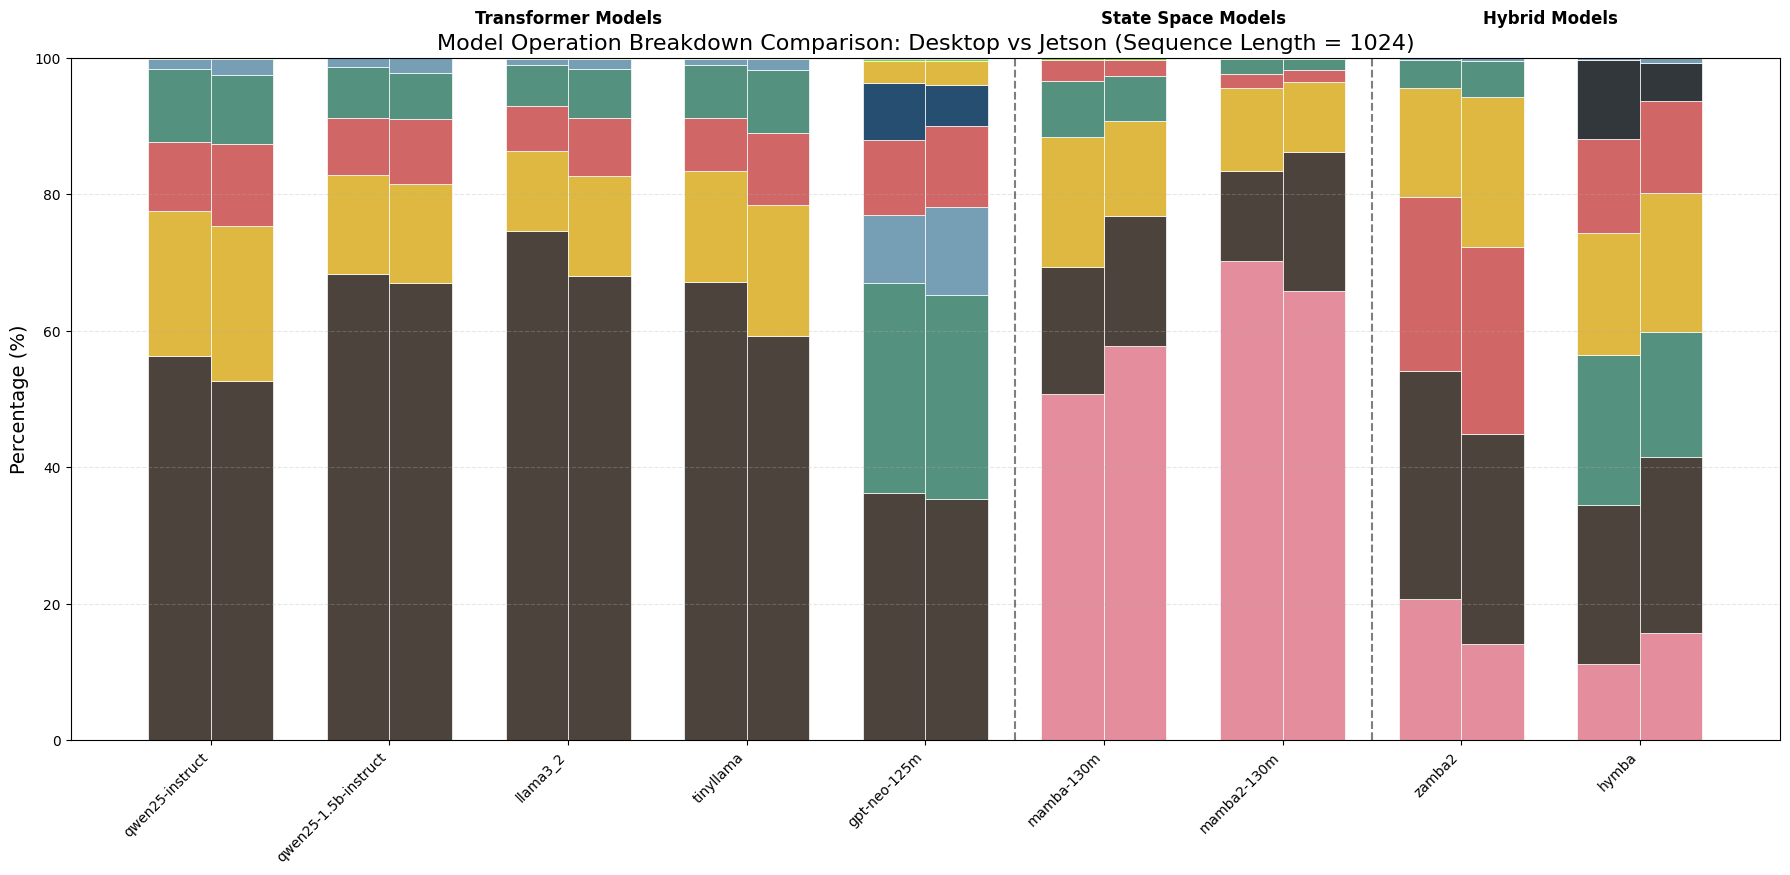

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys


# Directory where the profiling data is stored
prof_dir = '../../profile_data'
prof_dir_jetson = '../../profile_data_jetson'

# Make sure non-GEMM operations are summarized
summarize_non_gemm(prof_dir=prof_dir)
summarize_non_gemm(prof_dir=prof_dir_jetson)
# Define model categories for comparison
model_categories = {
    'Transformer Models': ['qwen25-instruct', 'qwen25-1.5b-instruct', 'llama3_2', 'tinyllama', 'gpt-neo-125m'],
    'State Space Models': ['mamba-130m', 'mamba2-130m'],
    'Hybrid Models': ['zamba2', 'hymba']
}

# Fixed sequence length for all models
seq_len = 1024

def extract_device_comparison_data(models, seq_len=1024, desktop_dir='plot_model', jetson_dir='plot_model_jetson'):
    """
    Extract operation breakdown data for models on both desktop and Jetson
    """
    comparison_data = {}
    
    for model in models:
        comparison_data[model] = {'desktop': None, 'jetson': None}
        
        # Try to load desktop data
        desktop_file = f"{desktop_dir}/{model}_cuda_1_{seq_len}/pct_{model}_cuda_1_{seq_len}.csv"
        if os.path.exists(desktop_file):
            desktop_df = pd.read_csv(desktop_file)
            comparison_data[model]['desktop'] = desktop_df
        else:
            print(f"Warning: Desktop data not found for {model} at sequence length {seq_len}")
        
        # Try to load Jetson data
        jetson_file = f"{jetson_dir}/{model}_cuda_1_{seq_len}/pct_{model}_cuda_1_{seq_len}.csv"
        if os.path.exists(jetson_file):
            jetson_df = pd.read_csv(jetson_file)
            comparison_data[model]['jetson'] = jetson_df
        else:
            print(f"Warning: Jetson data not found for {model} at sequence length {seq_len}")
    
    return comparison_data

def plot_device_comparison(model_categories, seq_len=1024, desktop_dir='plot_model', jetson_dir='plot_model_jetson'):
    """
    Create a side-by-side comparison of models on desktop vs Jetson
    """
    # Flatten the list of models
    all_models = []
    for category, models in model_categories.items():
        all_models.extend(models)
    
    # Extract data for all models
    comparison_data = extract_device_comparison_data(all_models, seq_len, desktop_dir, jetson_dir)
    
    # Filter out models with missing data
    valid_models = [model for model in all_models 
                    if comparison_data[model]['desktop'] is not None 
                    or comparison_data[model]['jetson'] is not None]
    
    if not valid_models:
        print("No valid data found for comparison")
        return
    
    # Create figure with appropriate size
    fig, ax = plt.subplots(figsize=(len(valid_models)*2, 10))
    
    # Set width of bars and positions
    bar_width = 0.35
    indices = np.arange(len(valid_models))
    
    # Collect all operation names from all models and calculate their average contribution
    all_ops = set()
    op_contributions = {}
    
    for model in valid_models:
        for device in ['desktop', 'jetson']:
            if comparison_data[model][device] is not None:
                df = comparison_data[model][device]
                for _, row in df.iterrows():
                    op_name = row['name']
                    all_ops.add(op_name)
                    
                    # Calculate contribution for this operation
                    contribution = row['pct'] if 'pct' in df.columns else row['total_time (us)']
                    
                    if op_name not in op_contributions:
                        op_contributions[op_name] = []
                    op_contributions[op_name].append(contribution)
    
    # Calculate average contribution for each operation
    for op in op_contributions:
        op_contributions[op] = sum(op_contributions[op]) / len(op_contributions[op])
    
    # Define operation order with SSM_Scan and GEMM at the bottom
    reserved_ops = ['SSM_Scan', 'GEMM']
    sortable_ops = [op for op in all_ops if op not in reserved_ops]
    
    # Sort remaining operations by their average contribution (highest to lowest)
    sorted_ops = sorted(sortable_ops, 
                       key=lambda op: op_contributions.get(op, 0), 
                       reverse=True)
    
    # Final operation order (reserved_ops at the bottom of the stack, which is first in the list)
    op_order = reserved_ops + sorted_ops
    
    # Create stacked bars for each model and device
    for i, model in enumerate(valid_models):
        # For each model, we'll sort the operations specifically for this model
        model_op_contributions = {}
        
        # Calculate the contribution of each operation for this specific model
        for device in ['desktop', 'jetson']:
            if comparison_data[model][device] is not None:
                df = comparison_data[model][device]
                for _, row in df.iterrows():
                    op_name = row['name']
                    if op_name not in reserved_ops:  # Only sort non-reserved ops
                        contribution = row['pct'] if 'pct' in df.columns else row['total_time (us)']
                        if op_name not in model_op_contributions:
                            model_op_contributions[op_name] = []
                        model_op_contributions[op_name].append(contribution)
        
        # Calculate average for each operation in this model
        for op in model_op_contributions:
            model_op_contributions[op] = sum(model_op_contributions[op]) / len(model_op_contributions[op])
        
        # Sort operations for this specific model (excluding reserved ops)
        model_sortable_ops = [op for op in sortable_ops if op in model_op_contributions]
        model_sorted_ops = sorted(model_sortable_ops, 
                                 key=lambda op: model_op_contributions.get(op, 0), 
                                 reverse=True)
        
        # Final operation order for this model
        model_op_order = reserved_ops + model_sorted_ops
        
        desktop_bottom = 0
        jetson_bottom = 0
        
        for op in model_op_order:
            # Get color for this operation
            if op in color_scheme:
                color = color_scheme[op]
            else:
                color = '#808080'  # Default gray for undefined ops
            
            # Get values for desktop
            desktop_val = 0
            if comparison_data[model]['desktop'] is not None:
                desktop_df = comparison_data[model]['desktop']
                if op in desktop_df['name'].values:
                    desktop_val = desktop_df[desktop_df['name'] == op]['pct'].values[0]
            
            # Get values for Jetson
            jetson_val = 0
            if comparison_data[model]['jetson'] is not None:
                jetson_df = comparison_data[model]['jetson']
                if op in jetson_df['name'].values:
                    jetson_val = jetson_df[jetson_df['name'] == op]['pct'].values[0]
            
            # Plot bars if values exist
            if desktop_val > 0:
                ax.bar(indices[i] - bar_width/2, desktop_val, bar_width, 
                       bottom=desktop_bottom, color=color, 
                       edgecolor='white', linewidth=0.5, 
                       label=op if i == 0 and desktop_bottom == 0 else "")
                desktop_bottom += desktop_val
            
            if jetson_val > 0:
                ax.bar(indices[i] + bar_width/2, jetson_val, bar_width, 
                       bottom=jetson_bottom, color=color, 
                       edgecolor='white', linewidth=0.5)
                jetson_bottom += jetson_val
    
    # Add category dividers and labels
    start_idx = 0
    for category, models in model_categories.items():
        # Count valid models in this category
        valid_category_models = [m for m in models if m in valid_models]
        if valid_category_models:
            category_len = len(valid_category_models)
            category_mid = start_idx + category_len / 2 - 0.5
            
            # Add vertical line as a category divider (except for the first category)
            if start_idx > 0:
                ax.axvline(x=start_idx-0.5, color='black', linestyle='--', alpha=0.5)
            
            # Add category label
            ax.text(category_mid, 105, category, ha='center', fontsize=12, fontweight='bold')
            
            start_idx += category_len
    
    # Create legend for desktop vs Jetson
    legend_desktop = plt.Rectangle((0,0), 1, 1, fill=False, edgecolor='none')
    legend_jetson = plt.Rectangle((0,0), 1, 1, fill=False, edgecolor='none')
    
    # # Create legend for operations (using the global sort order for consistency)
    # op_handles = []
    # op_labels = []
    # for op in op_order:
    #     if op in color_scheme:
    #         op_handles.append(plt.Rectangle((0,0), 1, 1, color=color_scheme[op]))
    #         op_labels.append(op)
    
    # # Add the desktop vs Jetson legend
    # ax.legend([legend_desktop, legend_jetson] + op_handles, 
    #           ["Desktop", "Jetson"] + op_labels,
    #           loc='upper center', bbox_to_anchor=(0.5, -0.05), 
    #           ncol=min(6, len(op_order)+2))
    
    # Set axis labels and title
    ax.set_title(f'Model Operation Breakdown Comparison: Desktop vs Jetson (Sequence Length = {seq_len})', fontsize=16)
    ax.set_ylabel('Percentage (%)', fontsize=14)
    ax.set_ylim(0, 100)
    
    # Set x-ticks and labels
    ax.set_xticks(indices)
    ax.set_xticklabels(valid_models, rotation=45, ha='right', fontsize=10)
    
    # # Add desktop and Jetson labels above the bars
    # for i in range(len(valid_models)):
    #     ax.text(i - bar_width/2, 102, "Desktop", ha='center', fontsize=8, rotation=90)
    #     ax.text(i + bar_width/2, 102, "Jetson", ha='center', fontsize=8, rotation=90)
    
    # Add grid for readability
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)  # Make space for the legend
    
    # Save figure
    # plt.savefig(f"device_comparison_seq{seq_len}.png", bbox_inches="tight", dpi=300)
    
    return fig, ax

# Generate the device comparison plot
fig, ax = plot_device_comparison(model_categories, seq_len, prof_dir, prof_dir_jetson)
plt.savefig(f"device_comparison_seq{seq_len}.png", bbox_inches="tight", dpi=300)
plt.show()